# Modellering av kundnöjdhet och lojalitet med en strukturell ekvationsmodell (PROC CALIS)

## Sammanfattning

Denna notebook anpassar en strukturell ekvationsmodell (SEM) för en detaljhandlare av konsumentvaror, och länkar två latenta drivkrafter — upplevd tjänstekvalitet och upplevt värde — till latent **nöjdhet**, och i sin tur till latent **lojalitet**. Med PROC CALIS och LINEQS-modelleringsspråket (Bentler-Weeks) estimeras mätmodellen för varje begrepp och de strukturella sambanden mellan dem samtidigt, vilket korrigerar de strukturella estimaten för mätfel.

På en undersökning med 100 respondenter passar modellen väl: chi-två = 50,81 med 49 frihetsgrader (p = 0,40), RMSEA = 0,019, CFI = 0,999, TLI = 0,998. De strukturella sambanden som återvunnits ur data är **nöjdhet på tjänstekvalitet = 0,51** och **på värde = 0,26**, samt **lojalitet på nöjdhet = 0,80** med ett litet direkt **lojalitet på värde = 0,15**. Lästa tillsammans färdas det mesta av värdets inflytande på lojalitet *genom* nöjdhet (indirekt effekt 0,26 × 0,80 = 0,21, jämfört med en direkt effekt på 0,15), och tjänstekvalitet når lojalitet nästan helt genom nöjdhet (0,51 × 0,80 = 0,41). Det praktiska budskapet: nöjdhet är den dominerande hävstången för lojalitet, och tjänstekvalitet är det effektivaste sättet att höja nöjdheten från första början.

## Datakällor

All data genereras inline i det första DATA-steget (inga externa filer). En latent "sann" nöjdhetsresa simuleras för varje respondent, och därefter observeras varje begrepp genom tre brusiga Likert-liknande indikatorfrågor.

| Dataset | Rader | Variabel | Roll | Beskrivning |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Respondentidentifierare |
| | | `q1`–`q3` | Indikatorer | Tjänstekvalitetsfrågor (latent ServQual) |
| | | `v1`–`v3` | Indikatorer | Upplevt värde-frågor (latent Value) |
| | | `s1`–`s3` | Indikatorer | Nöjdhetsfrågor (latent Satis) |
| | | `l1`–`l3` | Indikatorer | Lojalitetsfrågor (latent Loyal) |

Indikatorerna är kontinuerliga standardiserade poäng (centrerade ~0) byggda som `loading * latent + Normal noise`, så att mät- och strukturparametrarna som PROC CALIS återvinner är väl identifierade. ServQual och Value är korrelerade exogena latenta variabler; Satis regresseras på båda, och Loyal regresseras på Satis med ett mindre direkt samband från Value, vilket låter oss separera den indirekta kanalen (genom nöjdhet) från den direkta.

# Kundnöjdhet → Lojalitet: En strukturell ekvationsmodell

En detaljhandlare av konsumentvaror genomför en enkät efter köp för att förstå vad som driver återkommande affärer. Den arbetande teorin är en klassisk nöjdhet–lojalitetskedja:

- **Tjänstekvalitet** och **upplevt värde** är två distinkta saker som kunder upplever.
- Båda matar in i den övergripande **nöjdheten**.
- Nöjdhet driver i sin tur **lojalitet** (avsikt att återköpa / rekommendera).

Inget av dessa fyra begrepp observeras direkt. Vart och ett är *latent* och mäts av tre enkätfrågor. En strukturell ekvationsmodell (SEM) är rätt verktyg: den estimerar **mätmodellen** (hur frågor laddar på begrepp) och **strukturmodellen** (hur begrepp påverkar varandra) samtidigt, och korrigerar strukturella estimat för mätfel.

Vi använder **PROC CALIS** med modelleringsspråket **LINEQS** (Bentler-Weeks-notation).

## Steg 1 — Simulera en realistisk enkät

Vi genererar 100 respondenter. För varje drar vi de två korrelerade exogena drivkrafterna (tjänstekvalitet, värde), bygger sedan nöjdhet som en funktion av båda, och lojalitet som en funktion av nöjdhet plus en liten direkt värdeeffekt. Slutligen mäts varje begrepp av tre brusiga indikatorfrågor, precis som ett Likert-batteri skulle bete sig. `call streaminit` fastställer fröet för reproducerbarhet.

In [1]:
data survey;
   CALL streaminit(20260531);
   GÖR respid = 1 TILL 100;
      /* Two correlated exogenous latent drivers */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* perceived service quality */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* perceived value          */

      /* Structural model: satisfaction driven by both drivers */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalty driven mainly through satisfaction, small direct value path */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Measurement model: 3 indicators per latent construct */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      UTDATA;
   SLUT;
   BEHÅLL respid q1-q3 v1-v3 s1-s3 l1-l3;
KÖR;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Steg 2 — Inspektera de uppmätta frågorna

Före modelleringen tar vi en snabb titt på fördelningarna av frågorna och korrelationsstrukturen. Frågor inom ett begrepp bör korrelera starkt; frågor mellan begrepp svagare. Detta är vad en konfirmatorisk faktorstruktur antar.

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 q1             100       -0.23        1.24       -4.00        2.78
 q2             100       -0.13        1.13       -2.91        2.79
 q3             100       -0.16        1.12       -3.20        2.65
 v1             100       -0.03        1.09       -2.73        2.54
 v2             100       -0.05        1.12       -3.08        2.52
 v3             100       -0.00        0.93       -3.16        2.12
 s1             100       -0.11        0.97       -2.61        2.26
 s2             100       -0.23        1.01       -2.30        2.44
 s3             100       -0.08        0.90       -2.39        2.41
 l1             100       -0.03        1.03       -2.06        2.26
 l2             100       -0.06        0.95       -2.20        1.99
 l3             100       -0.11        0.86  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


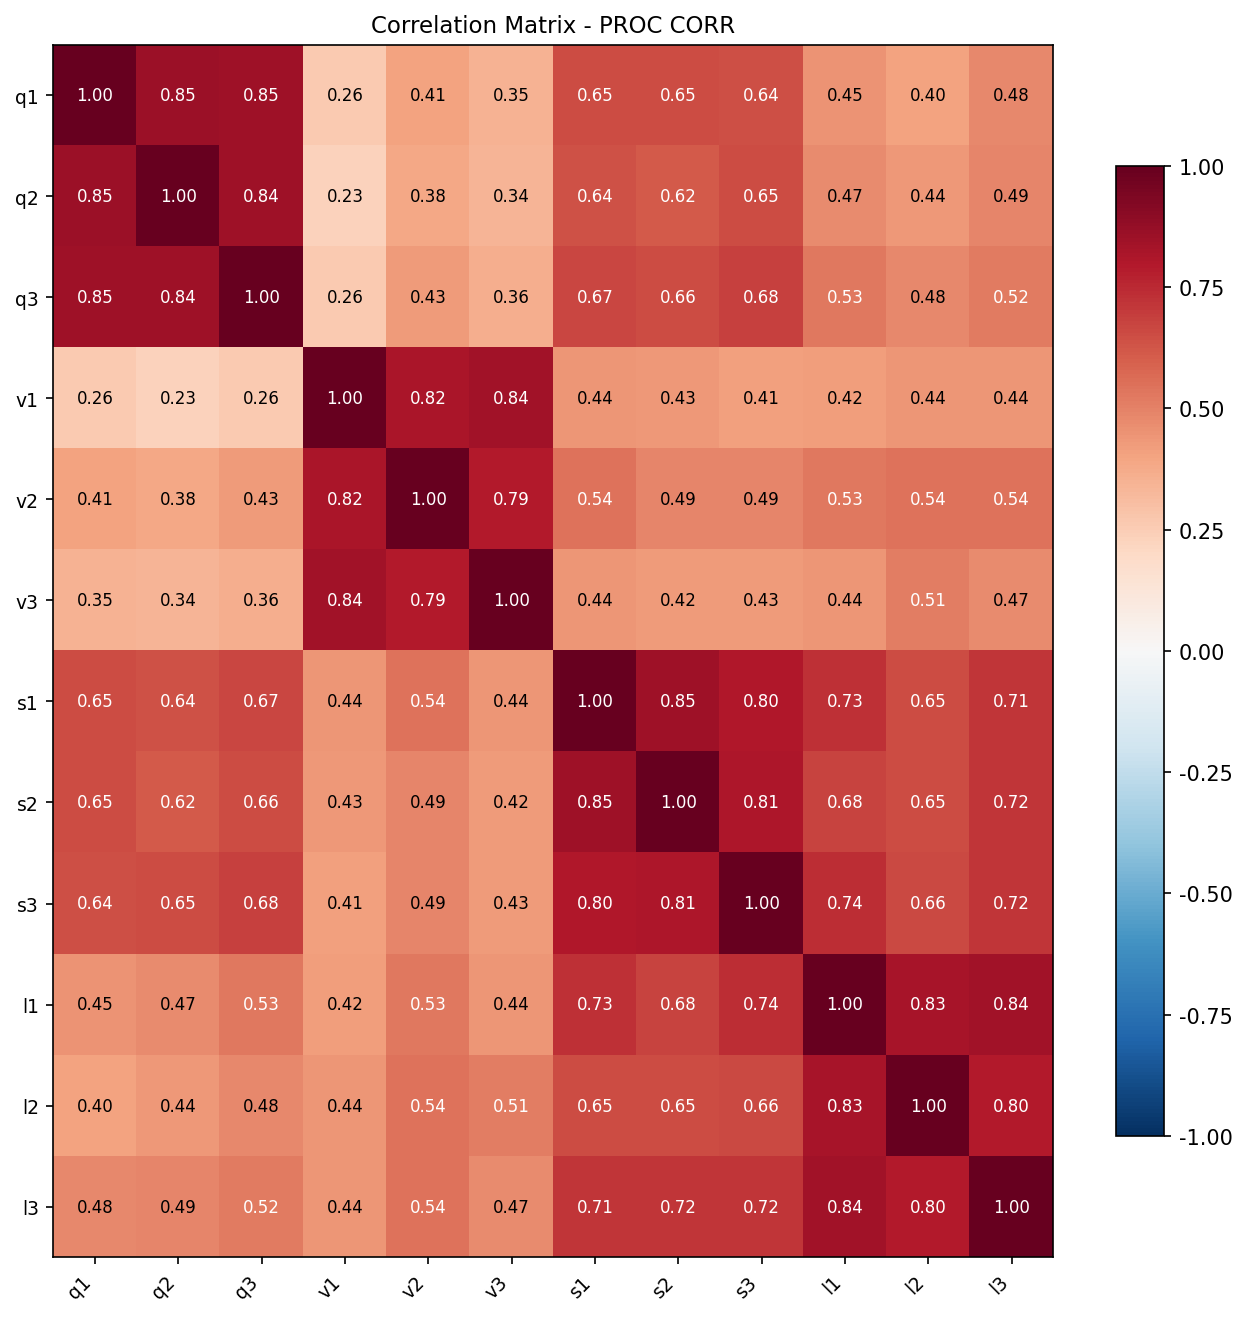

In [2]:
PROCEDUR MEDELVÄRDEN data=survey n mean std MIN MAX maxdec=2;
   VARIABEL q1-q3 v1-v3 s1-s3 l1-l3;
KÖR;

PROCEDUR CORR data=survey nosimple noprob;
   VARIABEL q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
KÖR;

## Steg 3 — Anpassa den fullständiga SEM-modellen

LINEQS-specifikationen har två lager:

**Mätekvationer** — varje observerad fråga är lika med en laddning gånger sin latenta faktor plus en unik felterm (`e1`–`e12`). Vi fixerar den första laddningen för varje begrepp till `1.0` för att sätta den latenta skalan; de återstående laddningarna är fria parametrar (namngivna `lq2`, `ls3`, ... så att de framträder med namn i utdata). Varje felterm deklareras i `variance`-satsen.

**Strukturella ekvationer** — `Satis` regresseras på `ServQual` och `Value`; `Loyal` regresseras på `Satis` och `Value` (ett litet direkt samband). Varje endogen latent variabel bär sin egen störningsterm (`d1` för nöjdhet, `d2` för lojalitet). Att namnge de strukturella koefficienterna (`b_sat_sq`, `b_loy_sat`, ...) gör dem lätta att läsa av i estimattabellen.

`variance`-satsen deklarerar de tolv mätfelsvarianserna, de två strukturella störningarna och de två exogena latenta varianserna; `cov ServQual Value` låter de två drivkrafterna korrelera. `method=ml` begär maximum-likelihood-estimering. Utdata rapporterar passningssammanfattningen (chi-två, RMSEA, CFI, TLI) och den fullständiga parameterestimattabellen med standardfel och t-värden.

In [3]:
PROCEDUR calis data=survey METHOD=ml toteff;
   lineqs
      /* --- Measurement model --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Structural model --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
KÖR;


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5477        0.4689        0.4775
q3                     -5.5689        1.1857        1.0745        1.2597        0.3199    


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Steg 4 — Visualisera de strukturella sambanden

De fyra strukturella koefficienterna som estimerats ovan är modellens kärna. Vi diagramlägger dem sida vid sida så att de relativa storlekarna — och dominansen hos sambandet nöjdhet → lojalitet — blir omedelbart synliga. De värden som plottas är maximum-likelihood-estimaten, avlästa direkt från parametertabellen i Steg 3.


NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


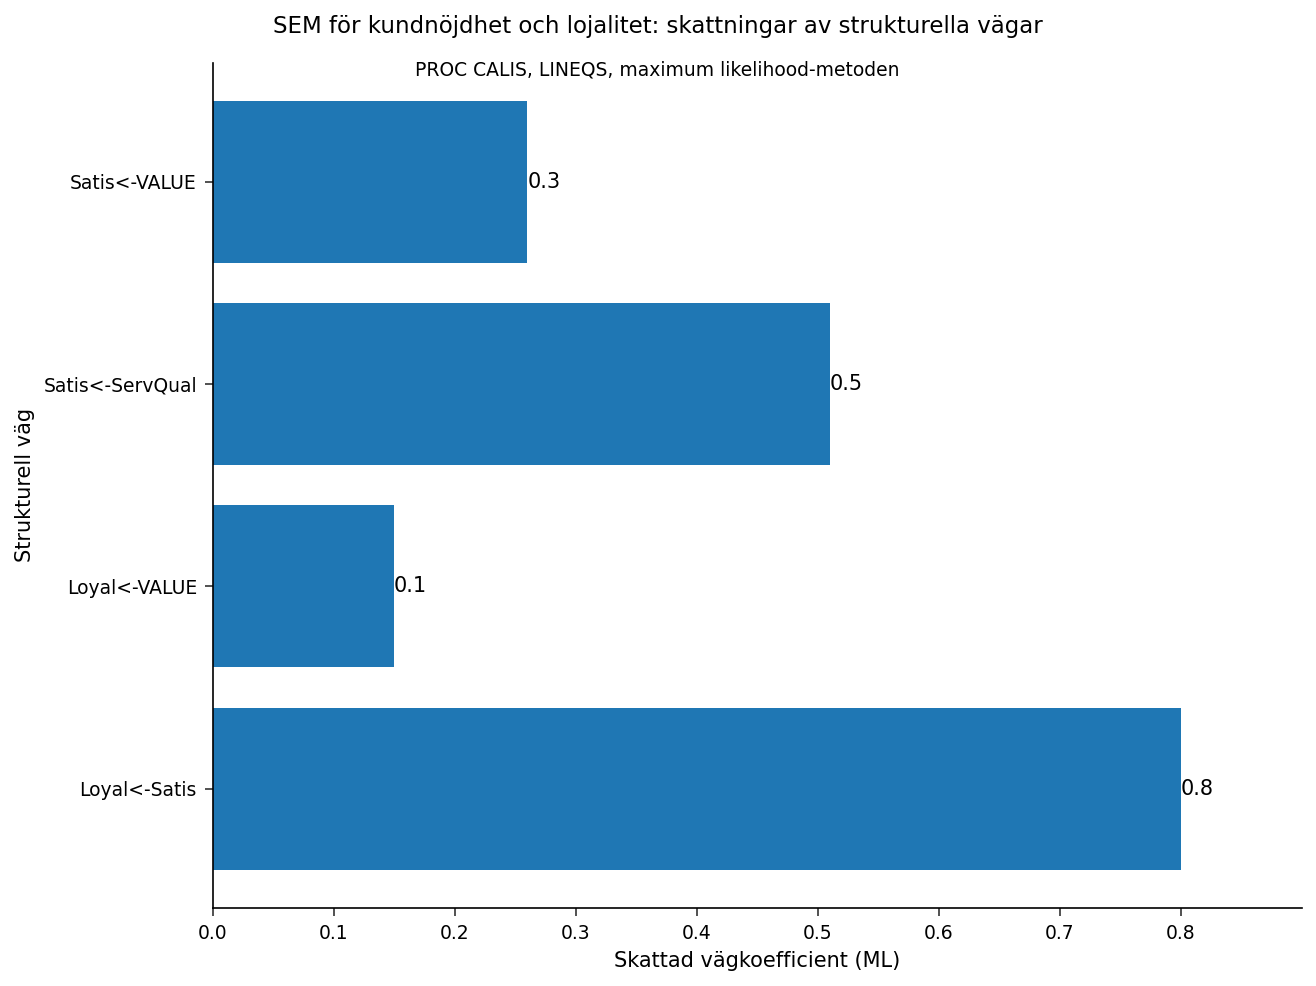

In [4]:
/* Structural path estimates from the PROC CALIS fit above */
data paths;
   LÄNGD path $18;
   INDATA path $ coef;
   DATALINES;
Loyal<-Satis 0.80
Satis<-ServQual 0.51
Satis<-VALUE 0.26
Loyal<-VALUE 0.15
;
KÖR;

PROCEDUR SGPLOT data=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS ETIKETT="Skattad vägkoefficient (ML)" MIN=0 MAX=0.9;
   YAXIS ETIKETT="Strukturell väg" discreteorder=data;
   TITEL  "SEM för kundnöjdhet och lojalitet: skattningar av strukturella vägar";
   title2 "PROC CALIS, LINEQS, maximum likelihood-metoden";
KÖR;

## Tolkning av resultaten

**Mätmodell.** Varje frigjord laddning är stor och starkt signifikant (alla t > 13, p < 0,0001): `q2`/`q3` laddar ~0,91 på ServQual, `v2`/`v3` laddar ~0,99 och 0,84 på Value, `s2`/`s3` laddar ~1,03 och 0,90 på Satis, och `l2`/`l3` laddar ~0,88 och 0,82 på Loyal. Felvarianserna är blygsamma i förhållande till indikatorvarianserna, så varje batteri med tre frågor mäter rent sitt avsedda begrepp — den validitetskontroll som motiverar att behandla frågorna som proxyvariabler för de latenta begreppen.

**Strukturmodell.** De estimerade sambanden svarar direkt på affärsfrågan:
- **Nöjdhet** drivs mer av **tjänstekvalitet** (`b_sat_sq` = 0,51, t = 7,99) än av **upplevt värde** (`b_sat_val` = 0,26, t = 3,86). Att investera i tjänstekvalitet flyttar nöjdheten ungefär dubbelt så mycket per enhet.
- **Lojalitet** domineras av **nöjdhet** (`b_loy_sat` = 0,80, t = 8,54) med endast ett litet *direkt* värdesamband (`b_loy_val` = 0,15, t = 2,02) som kringgår nöjdheten.
- De två drivkrafterna är positivt korrelerade (ServQual–Value-kovarians 0,44, t = 3,36), som väntat när båda återspeglar en gemensam underliggande upplevelse.

**Effektuppdelning.** Genom att multiplicera längs kedjan separeras den indirekta kanalen (genom nöjdhet) från den direkta:
- **Värde → Lojalitet:** indirekt = 0,26 × 0,80 = **0,21**, direkt = **0,15**, totalt ≈ **0,36**. Det mesta av värdets dragningskraft på lojalitet flödar genom nöjdhet.
- **Tjänstekvalitet → Lojalitet:** det finns inget direkt samband, så hela effekten är indirekt = 0,51 × 0,80 = **0,41** — den enskilt största drivkraften för lojalitet i modellen.

Detta kvantifierar det strategiska påståendet: *att förbättra nöjdheten är den primära hävstången för lojalitet*, och tjänstekvalitet är det effektivaste sättet att höja nöjdheten från första början.

**Passning.** Modellen återger de observerade kovarianserna väl — chi-två = 50,81 (df = 49, p = 0,40, ett icke-signifikant värde som indikerar ingen detekterbar felpassning), RMSEA = 0,019 (väl under tröskeln 0,05 för "nära passning"), CFI = 0,999 och TLI = 0,998 (båda över riktmärket 0,95). Den hypotiserade kedjan där nöjdhet medierar lojalitet är helt förenlig med data.

Kort sagt: detaljhandlaren kan avläsa hur mycket lojalitet som *tillverkas genom nöjdhet*, och vilken drivkraft — tjänstekvalitet eller värde — som mest effektivt höjer nöjdheten från första början.